# L=32 frozen ResNet-18 analysis

No spin inversion, supervised classifier, or conductance is used. The independent observations are seed-temperature means over the ten saved bins.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
TEMPERATURES = np.round(np.arange(2.2, 2.4001, 0.005), 3)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = Path.home() / "senior-thesis"
RAW_ROOT = REPO_ROOT / "data/raw/ising32_tc_zoom"
OUTPUT_ROOT = REPO_ROOT / "data/processed/ising32_tc_zoom"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

runs = sorted(RAW_ROOT.glob("ising32_tc_zoom_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(runs) == N_RUNS, len(runs)
print(f"{len(runs):,} runs; {len(TEMPERATURES)} temperatures; device={DEVICE}")

10,000 runs; 41 temperatures; device=cuda


Reduced 500/10,000 runs


Reduced 1,000/10,000 runs


Reduced 1,500/10,000 runs


Reduced 2,000/10,000 runs


Reduced 2,500/10,000 runs


...

Reduced 8,000/10,000 runs


Reduced 8,500/10,000 runs


Reduced 9,000/10,000 runs


Reduced 9,500/10,000 runs


Reduced 10,000/10,000 runs


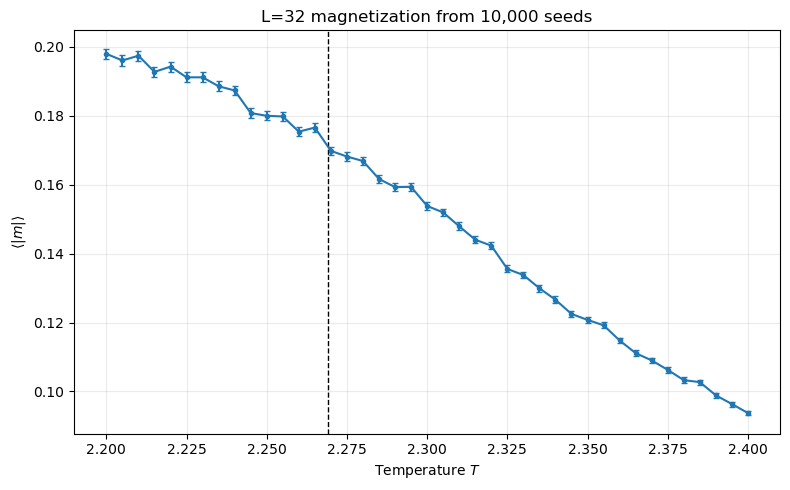

In [2]:
MEAN_SPINS_PATH = OUTPUT_ROOT / "seed_temperature_mean_spins.npy"
MAG_PATH = OUTPUT_ROOT / "seed_temperature_signed_magnetization.npy"

if not MEAN_SPINS_PATH.exists():
    mean_spins = np.lib.format.open_memmap(
        MEAN_SPINS_PATH, mode="w+", dtype=np.float16,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    magnetization = np.lib.format.open_memmap(
        MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        mean_spins[run_index] = spins.mean(axis=1)
        magnetization[run_index] = spins.mean(axis=(1, 2, 3), dtype=np.float64)
        if (run_index + 1) % 500 == 0:
            print(f"Reduced {run_index + 1:,}/{N_RUNS:,} runs")
    mean_spins.flush(); magnetization.flush()

mean_spins = np.load(MEAN_SPINS_PATH, mmap_mode="r")
magnetization = np.load(MAG_PATH, mmap_mode="r")
assert mean_spins.shape == (N_RUNS, N_TEMPERATURES, L, L)

mean_abs_m = np.abs(magnetization).mean(axis=0)
sem_abs_m = np.abs(magnetization).std(axis=0, ddof=1) / np.sqrt(N_RUNS)
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(TEMPERATURES, mean_abs_m, yerr=sem_abs_m, marker="o", ms=3, capsize=2)
ax.axvline(TC, color="black", ls="--", lw=1)
ax.set(xlabel="Temperature $T$", ylabel=r"$\langle |m|\rangle$", title="L=32 magnetization from 10,000 seeds")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising32_magnetization_zoom.png", dpi=250)
plt.show()

In [3]:
from torchvision.models import ResNet18_Weights, resnet18
import torch.nn.functional as F

EMBED_PATH = OUTPUT_ROOT / "resnet18_seed_temperature_embeddings.npy"
if not EMBED_PATH.exists():
    weights=ResNet18_Weights.DEFAULT; model=resnet18(weights=weights); model.fc=torch.nn.Identity(); model.eval().to(DEVICE)
    image_mean=torch.tensor(weights.transforms().mean,device=DEVICE).view(1,3,1,1); image_std=torch.tensor(weights.transforms().std,device=DEVICE).view(1,3,1,1)
    embeddings=np.lib.format.open_memmap(EMBED_PATH,mode="w+",dtype=np.float32,shape=(N_RUNS,N_TEMPERATURES,512))
    with torch.inference_mode():
        for ri,run_dir in enumerate(runs):
            name=run_dir.name; spins=np.loadtxt(run_dir/f"spinConfigs_{name}.txt",dtype=np.int8).reshape(N_TEMPERATURES,BINS_PER_TEMPERATURE,L,L)
            images=torch.from_numpy(spins.reshape(-1,L,L).astype(np.float32)).to(DEVICE).unsqueeze(1); images=(images+1)/2; images=images.repeat(1,3,1,1); images=F.interpolate(images,size=(224,224),mode="nearest"); images=(images-image_mean)/image_std
            embeddings[ri]=model(images).reshape(N_TEMPERATURES,BINS_PER_TEMPERATURE,512).mean(1).cpu().numpy()
            if (ri+1)%250==0: print(f"Embedded {ri+1:,}/{N_RUNS:,}")
    embeddings.flush()
embeddings=np.load(EMBED_PATH,mmap_mode="r").reshape(-1,512)
print(embeddings.shape)

Embedded 250/10,000


Embedded 500/10,000


Embedded 750/10,000


Embedded 1,000/10,000


Embedded 1,250/10,000


...

Embedded 9,000/10,000


Embedded 9,250/10,000


Embedded 9,500/10,000


Embedded 9,750/10,000


Embedded 10,000/10,000
(410000, 512)


In [4]:
def exact_pca(features, cache_name, batch_size=4096):
    cache = OUTPUT_ROOT / cache_name
    if cache.exists():
        data = np.load(cache)
        return data["mean"], data["eigenvalues"], data["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(features), batch_size):
        batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)
        total += batch.sum(0); second += batch.T @ batch
    mean_t = total / len(features)
    covariance = (second - len(features) * torch.outer(mean_t, mean_t)) / (len(features) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy(); eigenvalues = values[order].cpu().numpy(); components = vectors[:, order].T.cpu().numpy()
    np.savez(cache, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def score_memmap(features, mean, components, path, batch_size=8192):
    if path.exists(): return np.load(path, mmap_mode="r")
    scores = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(features), len(components)))
    for start in range(0, len(features), batch_size):
        stop = min(start + batch_size, len(features))
        scores[start:stop] = (np.asarray(features[start:stop], np.float32) - mean) @ components.T
    scores.flush(); return np.load(path, mmap_mode="r")

def variance_plot(eigenvalues, prefix):
    evr = eigenvalues / eigenvalues.sum(); cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .90) + 1)
    x = np.arange(1, n90 + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:n90], alpha=.8); ax.set(xlabel="PC", ylabel="Explained variance ratio", title=f"{prefix}: {n90} PCs retain 90%")
    other = ax.twinx(); other.plot(x, cumulative[:n90], "o-", color="tab:red", ms=3); other.axhline(.9, color="black", ls="--"); other.set_ylabel("Cumulative variance")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_variance.png", dpi=250); plt.show()
    return evr, cumulative, n90

def pc_visuals(scores, prefix):
    grids = mean_spins.reshape(-1, L, L)
    fig, axes = plt.subplots(5, 3, figsize=(10, 16), constrained_layout=True)
    rows=[]
    tail = max(1, int(.02 * len(scores)))
    for pc in range(5):
        values = np.asarray(scores[:, pc]); order = np.argsort(values)
        low, high = order[:tail], order[-tail:]
        low_map = np.asarray(grids[low], np.float32).mean(0); high_map = np.asarray(grids[high], np.float32).mean(0)
        for col,(data,title) in enumerate(((low_map,"lowest 2%"),(high_map,"highest 2%"),(high_map-low_map,"high-low"))):
            lim = 2 if col==2 else 1
            im=axes[pc,col].imshow(data,cmap="RdBu_r",vmin=-lim,vmax=lim); axes[pc,col].set_title(f"PC{pc+1} {title}"); axes[pc,col].set_xticks([]); axes[pc,col].set_yticks([]); fig.colorbar(im,ax=axes[pc,col],fraction=.046)
        rows.append({"pc":pc+1,"min_index":int(np.argmin(values)),"max_index":int(np.argmax(values)),"low_m":float(low_map.mean()),"high_m":float(high_map.mean())})
    fig.suptitle(f"{prefix} PC-tail mean spin fields"); fig.savefig(OUTPUT_ROOT / f"{prefix}_pc_tail_maps.png",dpi=250,bbox_inches="tight"); plt.show()
    pd.DataFrame(rows).to_csv(OUTPUT_ROOT / f"{prefix}_pc_tail_summary.csv",index=False)

def cluster_analysis(features, scores90, prefix):
    models = {"PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20), "Full": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20)}
    labels = {"PCA 90%": models["PCA 90%"].fit_predict(scores90), "Full": models["Full"].fit_predict(features)}
    flat_m = np.asarray(magnetization).reshape(-1)
    flat_t = np.tile(TEMPERATURES, N_RUNS)
    rows=[]
    for method, lab in labels.items():
        order=np.argsort([flat_m[lab==c].mean() for c in range(3)]); remap=np.empty(3,int); remap[order]=np.arange(3); lab=remap[lab]; labels[method]=lab
        for ti,t in enumerate(TEMPERATURES):
            at=lab[flat_t==t]
            for c in range(3): rows.append({"method":method,"temperature":t,"cluster":c,"fraction":float(np.mean(at==c))})
    table=pd.DataFrame(rows); table.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv",index=False)
    fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
    for ax,method in zip(axes,labels):
        for c in range(3):
            d=table[(table.method==method)&(table.cluster==c)]; ax.plot(d.temperature,d.fraction,"o-",ms=3,label=f"Cluster {c}")
        ax.axvline(TC,color="black",ls="--"); ax.set(title=method,xlabel="T",ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend()
    axes[0].set_ylabel("Cluster fraction"); fig.suptitle(f"{prefix} unsupervised clusters"); fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png",dpi=250); plt.show()
    np.savez(OUTPUT_ROOT / f"{prefix}_cluster_labels.npz",pca90=labels["PCA 90%"],full=labels["Full"])
    return labels

/tmp/ipykernel_65349/3413832967.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)


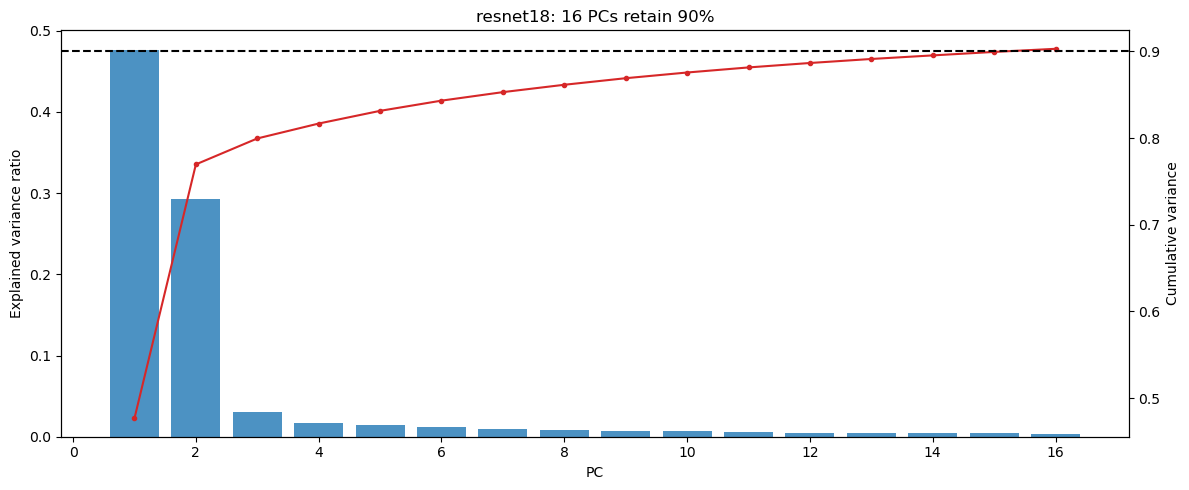

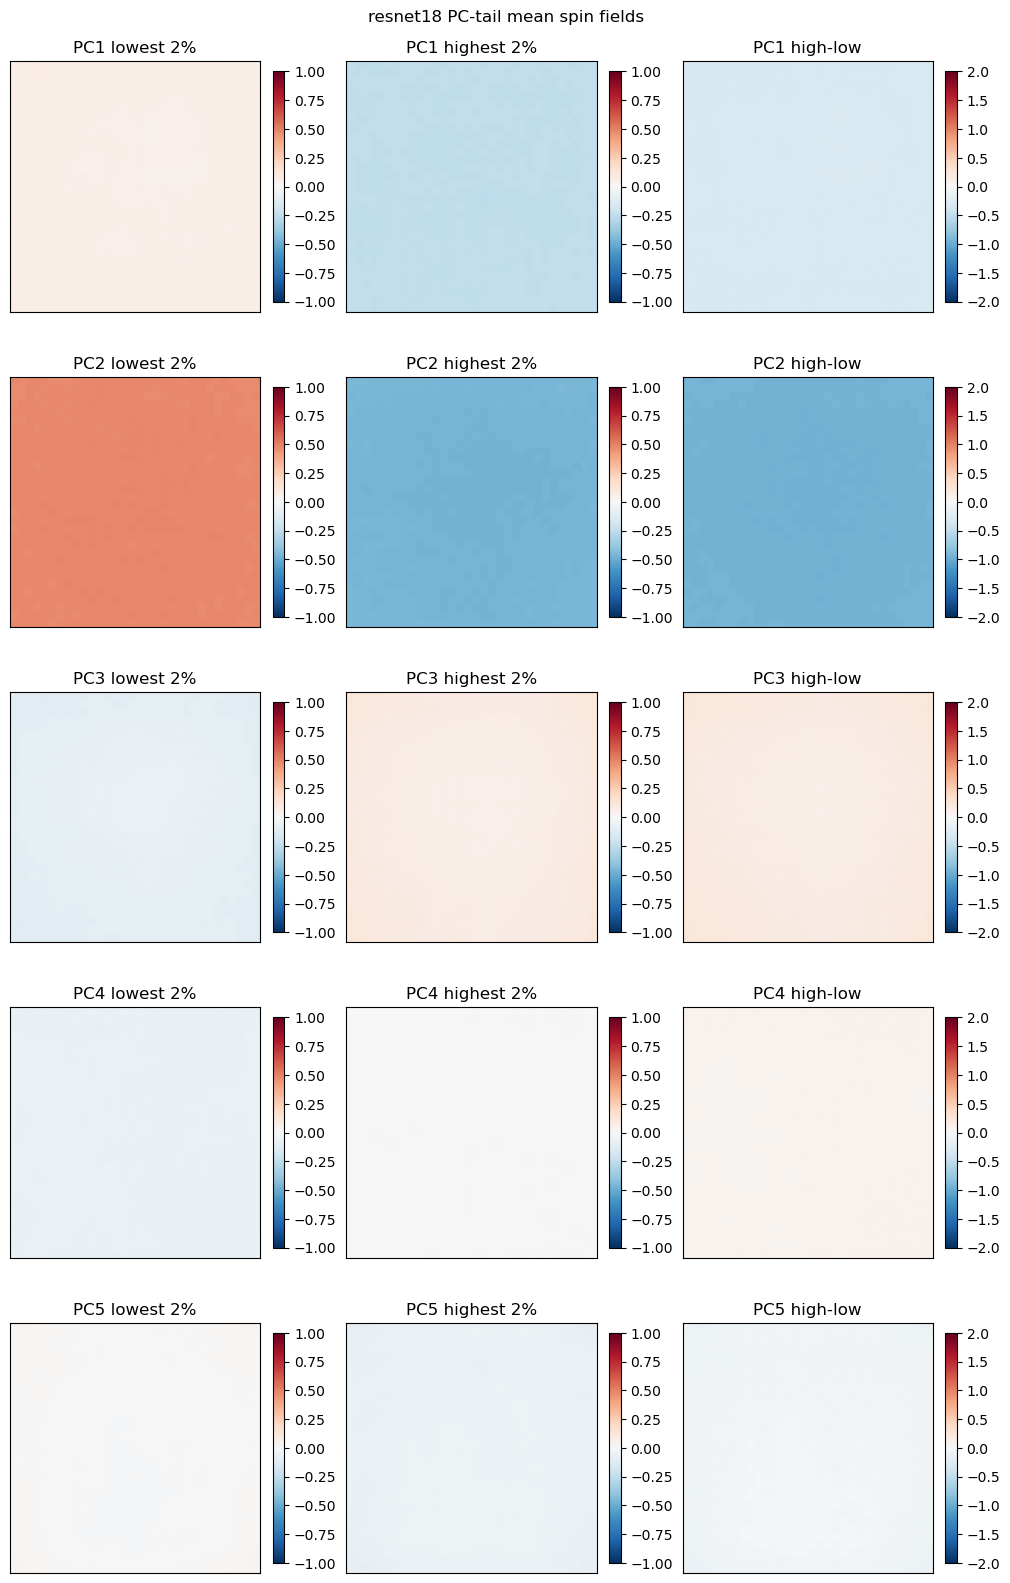

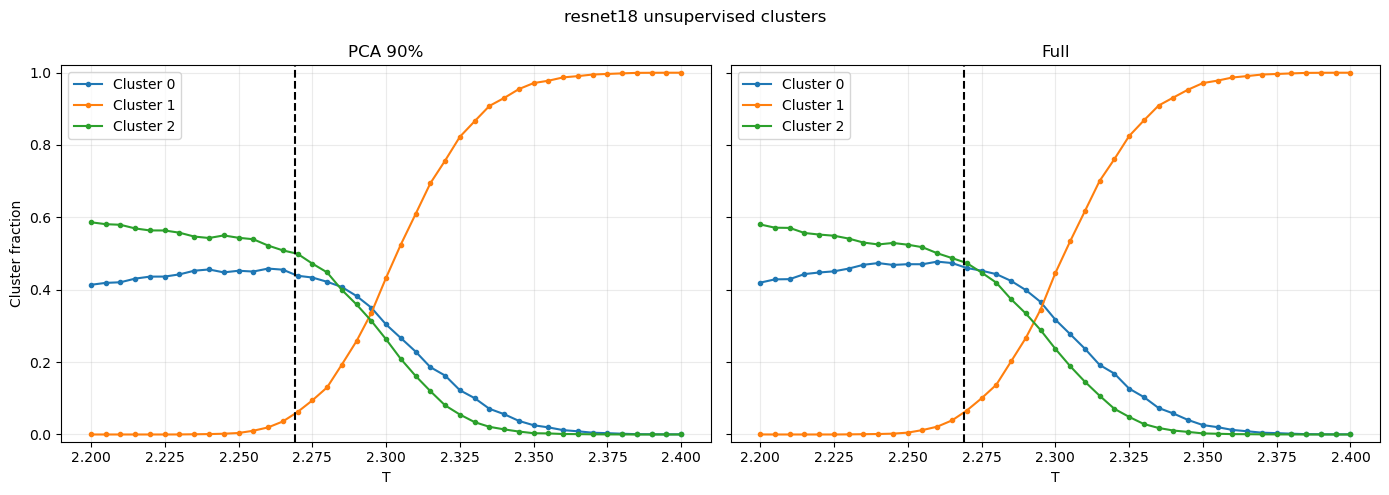

In [5]:
feature_mean,eigenvalues,components=exact_pca(embeddings,"resnet18_pca.npz")
evr,cumulative,n90=variance_plot(eigenvalues,"resnet18")
scores=score_memmap(embeddings,feature_mean,components[:n90],OUTPUT_ROOT/"resnet18_pca90_scores.npy")
pc_visuals(scores,"resnet18")
resnet_labels=cluster_analysis(embeddings,scores,"resnet18")
with open(OUTPUT_ROOT/"resnet18_summary.json","w") as f: json.dump({"n_components_90":n90,"variance_first5":evr[:5].tolist()},f,indent=2)